# Q_2: Car Prices

This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

##   1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv('cars_hw.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


In [3]:
# lets make correct columns into categorical columns

cat_cols = ["Make", "Make_Year", "Color",
            "Body_Type", "Fuel_Type", 
            "Transmission", "Transmission_Type",
            "No_of_Owners"
            ]

data[cat_cols] = data[cat_cols].astype("category")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Unnamed: 0         976 non-null    int64   
 1   Make               976 non-null    category
 2   Make_Year          976 non-null    category
 3   Color              976 non-null    category
 4   Body_Type          976 non-null    category
 5   Mileage_Run        976 non-null    int64   
 6   No_of_Owners       976 non-null    category
 7   Seating_Capacity   976 non-null    int64   
 8   Fuel_Type          976 non-null    category
 9   Transmission       976 non-null    category
 10  Transmission_Type  976 non-null    category
 11  Price              976 non-null    int64   
dtypes: category(8), int64(4)
memory usage: 39.0 KB


In [4]:
# price is heavily skewed
# lets find the log price

data["Log Price"] = np.log(data["Price"])

In [5]:
keep = ['Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Log Price']

cars = data[keep].copy()
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Make               976 non-null    category
 1   Make_Year          976 non-null    category
 2   Color              976 non-null    category
 3   Body_Type          976 non-null    category
 4   Mileage_Run        976 non-null    int64   
 5   No_of_Owners       976 non-null    category
 6   Seating_Capacity   976 non-null    int64   
 7   Fuel_Type          976 non-null    category
 8   Transmission       976 non-null    category
 9   Transmission_Type  976 non-null    category
 10  Log Price          976 non-null    float64 
dtypes: category(8), float64(1), int64(2)
memory usage: 31.4 KB


Now we have clean data to use.

##   2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [6]:
print(cars.groupby("Make")["Log Price"].describe().sort_values(ascending = False, by = "mean"))

               count       mean       std        min        25%        50%  \
Make                                                                         
MG Motors       35.0  14.439052  0.066263  14.278615  14.395744  14.429615   
Kia              8.0  14.292177  0.076877  14.129591  14.272242  14.303105   
Jeep             4.0  14.216591  0.105084  14.070153  14.183270  14.240265   
Mahindra        18.0  13.898953  0.159906  13.587354  13.851808  13.905680   
Tata            23.0  13.713405  0.615090  12.144197  13.566383  13.675098   
Nissan           4.0  13.641194  0.392610  13.071070  13.537775  13.788723   
Skoda            5.0  13.640864  0.827046  12.985398  13.051941  13.195614   
Honda           73.0  13.536318  0.336972  12.663497  13.272506  13.573439   
Toyota          50.0  13.535507  0.360112  12.815838  13.171414  13.703461   
Ford            52.0  13.468280  0.210895  12.577636  13.361380  13.469493   
Hyundai        305.0  13.368511  0.398781  12.421184  13.091904 

Text(0.5, 0.98, 'KDE Plot of Log Price by Make')

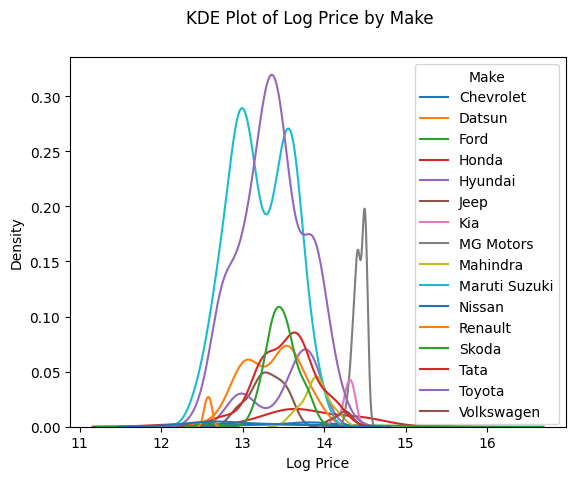

In [7]:
sns.kdeplot(cars, x = 'Log Price' , hue = 'Make', palette = "tab10")
plt.suptitle("KDE Plot of Log Price by Make")

The most expensive ar brands on average are MG Motors, Kia, and Jeep. In general, most car prices seem to have the same range and very similar mean prices, with the exception of MG Motors. However, some brands have a larger price range, while others have a larger density around specific prices. 

##   3. Split the data into an 80% training set and a 20% testing set.

In [8]:
prefixes = ["Make", "Year", "Color", "Owner", "Body", "Fuel", "Trans_num", "Trans_type"]
cars = pd.get_dummies(cars , columns= cat_cols , drop_first= True, prefix = prefixes)

In [9]:
cars.columns

Index(['Mileage_Run', 'Seating_Capacity', 'Log Price', 'Make_Datsun',
       'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia',
       'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan',
       'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota',
       'Make_Volkswagen', 'Year_2012', 'Year_2013', 'Year_2014', 'Year_2015',
       'Year_2016', 'Year_2017', 'Year_2018', 'Year_2019', 'Year_2020',
       'Year_2021', 'Year_2022', 'Color_black', 'Color_blue', 'Color_bronze',
       'Color_brown', 'Color_golden', 'Color_green', 'Color_grey',
       'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red',
       'Color_silver', 'Color_white', 'Color_yellow', 'Owner_hatchback',
       'Owner_muv', 'Owner_sedan', 'Owner_suv', 'Body_petrol',
       'Body_petrol+cng', 'Fuel_5-Speed', 'Fuel_6-Speed', 'Fuel_7-Speed',
       'Fuel_CVT', 'Trans_num_Manual', 'Trans_type_2nd', 'Trans_type_3rd'],
      dtype='str')

In [10]:
cols = ['Mileage_Run', 'Seating_Capacity', 'Make_Datsun',
       'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia',
       'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan',
       'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota',
       'Make_Volkswagen', 'Year_2012', 'Year_2013', 'Year_2014', 'Year_2015',
       'Year_2016', 'Year_2017', 'Year_2018', 'Year_2019', 'Year_2020',
       'Year_2021', 'Year_2022', 'Color_black', 'Color_blue', 'Color_bronze',
       'Color_brown', 'Color_golden', 'Color_green', 'Color_grey',
       'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red',
       'Color_silver', 'Color_white', 'Color_yellow', 'Owner_hatchback',
       'Owner_muv', 'Owner_sedan', 'Owner_suv', 'Body_petrol',
       'Body_petrol+cng', 'Fuel_5-Speed', 'Fuel_6-Speed', 'Fuel_7-Speed',
       'Fuel_CVT', 'Trans_num_Manual', 'Trans_type_2nd', 'Trans_type_3rd']
X_final = cars[cols]
y_final = cars.loc[X_final.index, 'Log Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42)

##   4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [20]:
# Numeric variable model

numeric_cols = ['Mileage_Run', 'Seating_Capacity']


model_numeric = LinearRegression(fit_intercept=True).fit(X_train[numeric_cols], y_train)

y_pred = model_numeric.predict(X_test[numeric_cols])

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.18
Root Mean Squared Error (RMSE): 0.42
R² Score: 0.0821


In [22]:
# Categorical Variable Model

cat_cols = ['Make_Datsun', 'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep',
            'Make_Kia', 'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan',
            'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota','Make_Volkswagen', 
            'Year_2012', 'Year_2013', 'Year_2014', 'Year_2015', 'Year_2016', 'Year_2017', 
            'Year_2018', 'Year_2019', 'Year_2020', 'Year_2021', 'Year_2022', 'Color_black',
            'Color_blue', 'Color_bronze', 'Color_brown', 'Color_golden', 'Color_green', 
            'Color_grey', 'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red',
            'Color_silver', 'Color_white', 'Color_yellow', 'Owner_hatchback', 'Owner_muv', 
            'Owner_sedan', 'Owner_suv', 'Body_petrol', 'Body_petrol+cng', 'Fuel_5-Speed', 
            'Fuel_6-Speed', 'Fuel_7-Speed', 'Fuel_CVT', 'Trans_num_Manual', 'Trans_type_2nd', 
            'Trans_type_3rd'
            ]

model_cat = LinearRegression(fit_intercept=True).fit(X_train[cat_cols], y_train)

y_pred = model_cat.predict(X_test[cat_cols])

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.20
R² Score: 0.8002


The categorical model performed better with a smaller RMSE of 0.2 and a larger $R^2$-value of 0.8002. 

In [23]:
# model with both numeric and categorical categories

model_full = LinearRegression(fit_intercept=True).fit(X_train, y_train)

y_pred = model_full.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.19
R² Score: 0.8126


Yes, the joint model performs better than both the categorical and numerical models. Compared to the numerical model the $R^2$-value of the joint model is larger by nearly 10x and the RMSE value is smaller by 0.23. Compared to the categorical model the $R^2$-value of the joint model is larger by 0.0124 and the RMSE value is smaller by 0.01.

##   5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [14]:
degrees = range(1, 20)
cat_cols = ['Make_Datsun',
        'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia',
       'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan',
       'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota',
       'Make_Volkswagen', 'Year_2012', 'Year_2013', 'Year_2014', 'Year_2015',
       'Year_2016', 'Year_2017', 'Year_2018', 'Year_2019', 'Year_2020',
       'Year_2021', 'Year_2022', 'Color_black', 'Color_blue', 'Color_bronze',
       'Color_brown', 'Color_golden', 'Color_green', 'Color_grey',
       'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red',
       'Color_silver', 'Color_white', 'Color_yellow', 'Owner_hatchback',
       'Owner_muv', 'Owner_sedan', 'Owner_suv', 'Body_petrol',
       'Body_petrol+cng', 'Fuel_5-Speed', 'Fuel_6-Speed', 'Fuel_7-Speed',
       'Fuel_CVT', 'Trans_num_Manual', 'Trans_type_2nd', 'Trans_type_3rd'
       ]
numeric_cols = ['Mileage_Run', 'Seating_Capacity']

poly_deg = []
root_mean_se = []
r_2 = []

X_full = cars[cat_cols + numeric_cols]
y_full = cars['Log Price']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly.fit_transform(X_train_full[numeric_cols]) 
    X_poly_test = poly.transform(X_test_full[numeric_cols]) 

    X_train_model = np.hstack([X_poly_train, X_train_full[cat_cols].values])  
    X_test_model = np.hstack([X_poly_test, X_test_full[cat_cols].values])     

    model = LinearRegression().fit(X_train_model, y_train_full)
    y_pred_poly = model.predict(X_test_model)

    mse = mean_squared_error(y_test_full, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_full, y_pred_poly)

    poly_deg.append(degree)
    root_mean_se.append(rmse)
    r_2.append(r2)

poly_df = pd.DataFrame({
    'Degree': poly_deg,
    'RMSE': root_mean_se,
    'R2': r_2
})
print(poly_df)


    Degree      RMSE        R2
0        1  0.189058  0.812573
1        2  0.188682  0.813318
2        3  0.419585  0.076829
3        4  0.421083  0.070225
4        5  0.421335  0.069115
5        6  0.420923  0.070935
6        7  0.422317  0.064771
7        8  0.426556  0.045900
8        9  0.433560  0.014309
9       10  0.421539  0.068210
10      11  0.423526  0.059405
11      12  0.426004  0.048369
12      13  0.428922  0.035289
13      14  0.432148  0.020723
14      15  0.435381  0.006013
15      16  0.438138 -0.006616
16      17  0.439892 -0.014691
17      18  0.440338 -0.016748
18      19  0.439596 -0.013327


In [15]:
# model with the lowest RMSE
print(poly_df.sort_values(by="RMSE" , ascending = True))

    Degree      RMSE        R2
1        2  0.188682  0.813318
0        1  0.189058  0.812573
2        3  0.419585  0.076829
5        6  0.420923  0.070935
3        4  0.421083  0.070225
4        5  0.421335  0.069115
9       10  0.421539  0.068210
6        7  0.422317  0.064771
10      11  0.423526  0.059405
11      12  0.426004  0.048369
7        8  0.426556  0.045900
12      13  0.428922  0.035289
13      14  0.432148  0.020723
8        9  0.433560  0.014309
14      15  0.435381  0.006013
15      16  0.438138 -0.006616
18      19  0.439596 -0.013327
16      17  0.439892 -0.014691
17      18  0.440338 -0.016748


In [16]:
print(poly_df.sort_values(by="R2" , ascending = False))

    Degree      RMSE        R2
1        2  0.188682  0.813318
0        1  0.189058  0.812573
2        3  0.419585  0.076829
5        6  0.420923  0.070935
3        4  0.421083  0.070225
4        5  0.421335  0.069115
9       10  0.421539  0.068210
6        7  0.422317  0.064771
10      11  0.423526  0.059405
11      12  0.426004  0.048369
7        8  0.426556  0.045900
12      13  0.428922  0.035289
13      14  0.432148  0.020723
8        9  0.433560  0.014309
14      15  0.435381  0.006013
15      16  0.438138 -0.006616
18      19  0.439596 -0.013327
16      17  0.439892 -0.014691
17      18  0.440338 -0.016748


As the number of degrees increase the RMSE-value increase. This is not a completely linear trend, but overall the RMSE-value increases as degree increases. Similarly, as the number of degrees increase the $R^2$ decreases. This is not a completely linear trend, but overall the $R^2$ decreases as degree increases. $R^2$ goes from positive to negative when you go from a 15 degree polynomial to a 16 degree polynomial. The best model is with degree 2 on the numeric columns. The $R^2$ is 0.813 and RMSE is 0.1886. This has a slightly lower RMSE (0.0004 lower) and a slightly higher $R^2$ value (0.0008 higher). These are very minute changes, but make the model more accurate.

 ## 6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [17]:
# model with degree 2
# this was our best model

cat_cols = ['Make_Datsun',
        'Make_Ford', 'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia',
       'Make_MG Motors', 'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan',
       'Make_Renault', 'Make_Skoda', 'Make_Tata', 'Make_Toyota',
       'Make_Volkswagen', 'Year_2012', 'Year_2013', 'Year_2014', 'Year_2015',
       'Year_2016', 'Year_2017', 'Year_2018', 'Year_2019', 'Year_2020',
       'Year_2021', 'Year_2022', 'Color_black', 'Color_blue', 'Color_bronze',
       'Color_brown', 'Color_golden', 'Color_green', 'Color_grey',
       'Color_maroon', 'Color_orange', 'Color_purple', 'Color_red',
       'Color_silver', 'Color_white', 'Color_yellow', 'Owner_hatchback',
       'Owner_muv', 'Owner_sedan', 'Owner_suv', 'Body_petrol',
       'Body_petrol+cng', 'Fuel_5-Speed', 'Fuel_6-Speed', 'Fuel_7-Speed',
       'Fuel_CVT', 'Trans_num_Manual', 'Trans_type_2nd', 'Trans_type_3rd'
       ]
numeric_cols = ['Mileage_Run', 'Seating_Capacity']



X_full = cars[cat_cols + numeric_cols]
y_full = cars['Log Price']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train_full[numeric_cols]) 
X_poly_test = poly.transform(X_test_full[numeric_cols]) 

X_train_model = np.hstack([X_poly_train, X_train_full[cat_cols].values])  
X_test_model = np.hstack([X_poly_test, X_test_full[cat_cols].values])     

model = LinearRegression().fit(X_train_model, y_train_full)
y_pred_poly = model.predict(X_test_model)


mse = mean_squared_error(y_test_full, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_full, y_pred_poly)


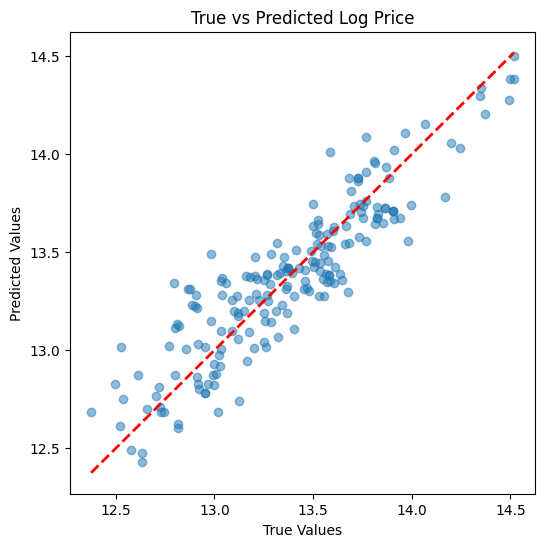

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_full, y_pred_poly, alpha=0.5)
plt.plot([y_test_full.min(), y_test_full.max()], 
         [y_test_full.min(), y_test_full.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Log Price')
plt.show()

Yes, they roughly line up along the diagonal

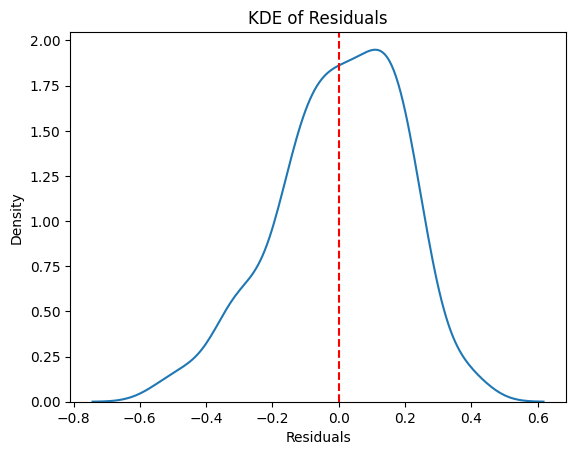

In [19]:
residuals = y_test_full - y_pred_poly

sns.kdeplot(residuals)
plt.axvline(x=0, color='r', linestyle='--') 
plt.xlabel('Residuals')
plt.title('KDE of Residuals')
plt.show()

Yes, the residuals look roughly bell-shaped around 0. My model is pretty well balanced and with a $R^2$ values of 0.813 means that 81.3% of the price of a car can be explained by this data. That is a pretty strong statistic. However, looking at the bellcurve, it seems that a larger portion of my residual distribution is positive, meaning that my model might overpredict the price of a car compared to what it actually should be. If I had more time, I would adjust parameters or features to make this distribution more even overall. 